## Introduction

In this code, the Land Surface Temperature (LST) is computed using the thermal band (band 10) of Landsat 8 - Landsat Collection 2 Level 2 Dataset. Rather than modifying this (thermal), one can also use the values of the band as a direct measure for LST. 

This code is written in geemap. The code is largely based on the code of Ujaval Gandhi (2021, supplement) for the "Derive LST from Landsat Images'.

In this script, the Python geemap package is used. In order to convert the JavaScript (JS) code of Google Earth Engine (GEE) into geemap, we used the conversion Python command ["Geemap "geemap.js_snippet_to_py" command"](https://book.geemap.org/chapters/03_gee_data.html#converting-javascript-to-python) that is available in the geemap package. 

In this code, the water pixels are masked out. This follows the work of Chakraborty (2023). When looking at the road density per ward, it makes much sense to mask out the water pixels as otherwise incorporating the water pixels in the LST computation can distort the mean LST computation per ward.

## Importing the libraries

In [1]:
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import pandas as pd

In [2]:
cloud_project = 'ee-ellenarun2'

try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)

## Reading in and preparing the data

In [3]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [5]:
# https://geemap.org/notebooks/10_shapefiles/ 
# Convert to something geemap can understand
chennai = geemap.shp_to_ee(df_inpath)

In [6]:
print(f'The number of wards in Chennai is {chennai.size().getInfo()}')

The number of wards in Chennai is 200


In [7]:
chennaiGeometry = chennai.union(50)

Map = geemap.Map()
Map.centerObject(chennaiGeometry, zoom=10)
Map # Uncomment if you want to see the map. 
## Otherwise you can wait till later Maps as all layers are in them

Map(center=[13.063596024256674, 80.231179751739], controls=(WidgetControl(options=['position', 'transparent_bg…

In [9]:
Map.addLayer(chennaiGeometry, {}, 'Chennai outline')
Map

Map(bottom=121776.0, center=[13.063596024256674, 80.231179751739], controls=(WidgetControl(options=['position'…

In [10]:
## Add the ward data
image = ee.Image().paint(chennai, 0, 2)
Map.addLayer(image, {'palette': 'red'}, "Chennai geometry")
Map

Map(bottom=121776.0, center=[13.063596024256674, 80.231179751739], controls=(WidgetControl(options=['position'…

## Computing the Land Surface Temperature

In [11]:
# https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2#colab-python
# Applies scaling factors.
# def apply_scale_factors(image):
#   optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
#   thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
#   return image.addBands(optical_bands, None, True).addBands(
#       thermal_bands, None, True
#   )

In [12]:
colThsummer = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
.filterBounds(chennaiGeometry) \
.filterDate('2024-01-01', '2025-11-01') \
.filter(ee.Filter.calendarRange(3, 5, 'month')) 

In [13]:
## colThsummer

In [14]:
def maskL8sr(image):
    ## Code obtained from:
    ## https://courses.spatialthoughts.com/end-to-end-gee-supplement.html#derive-lst-from-landsat-images 
    qaMask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturationMask = image.select('QA_RADSAT').eq(0)

    # Scaling factors
    opticalBands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermalBands = image.select('ST_B.*').multiply(0.00341802).add(149.0)

    # Replace the original bands with the scaled ones and apply the masks.
    return image.addBands(opticalBands, None, True) \
    .addBands(thermalBands, None, True) \
    .updateMask(qaMask) \
    .updateMask(saturationMask)


In [15]:
colThsummer = colThsummer.map(maskL8sr)
## colThsummer

In [16]:
imageThsummer = colThsummer.median()
## imageThsummer

In [17]:
image_clipped = imageThsummer.clip(chennaiGeometry)

visualisation = {
  'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 
  'min': 0,
  'max': 0.5,
  'gamma': [0.95, 1.1, 1]
}

Map.addLayer(image_clipped, visualisation, 'True Color Composite Chennai')

Map

Map(bottom=121776.0, center=[13.063596024256674, 80.231179751739], controls=(WidgetControl(options=['position'…

In [18]:
thermalsummer = imageThsummer.select('ST_B10') \
.clip(chennaiGeometry) \

Map.addLayer(thermalsummer, {
"min": 280,
"max": 330,
"palette": ['blue', 'white', 'red']},'Landsat_BT')

Map

Map(bottom=121776.0, center=[13.063596024256674, 80.231179751739], controls=(WidgetControl(options=['position'…

In [19]:
## Convert to Celsius
thermal_summer_c = (
thermalsummer
.clip(chennaiGeometry)
.subtract(273.15)
.rename('LST_C')
)

In [20]:
Map.addLayer(thermal_summer_c, {
    "min": 35,
    "max": 42,
    "palette": ['blue', 'white', 'red'],
},
'LST_Landsat')

vis_params = {'min': 35, 'max': 42, 'palette': ['blue', 'white', 'red']}
Map.add_colorbar(vis_params, label='Land Surface Temperature (°C)',position= 'bottomright')
Map

Map(bottom=121776.0, center=[13.063596024256674, 80.231179751739], controls=(WidgetControl(options=['position'…

Mask the pixels for water. We use the method for water masking of Chakraborty (2023):

In [21]:
# Generate a water mask.
water = ee.Image('JRC/GSW1_0/GlobalSurfaceWater').select(
'occurrence')
notWater = water.mask().Not()

In [22]:
thermal_summer_c_masked = thermal_summer_c.updateMask(notWater)

In [23]:
Map.addLayer(thermal_summer_c_masked, {
    "min": 35,
    "max": 42,
    "palette": ['blue', 'white', 'red'],
},
'LST_Landsat water masked')

vis_params = {'min': 35, 'max': 42, 'palette': ['blue', 'white', 'red']}
# Map.add_colorbar(vis_params, label='Land Surface Temperature (°C)',position= 'bottomright')
Map

Map(bottom=1945331.0, center=[12.945090185150542, 80.19663333892822], controls=(WidgetControl(options=['positi…

## Zonal statistics for LST

In [24]:
lstwardsmanualsummer = thermal_summer_c_masked.reduceRegions(
collection=chennai,
reducer=ee.Reducer.mean(),
scale=30,
)

In [26]:
## lstwardsmanualsummer

In [27]:
lstwardsmanualsummer = lstwardsmanualsummer.select(['Name', 'zone_id', 'zone_name', 'mean'])

In [28]:
outdir = PROCESSED_DIR /'lstband10summer_chennai_masked.csv'
print(outdir)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_chennai_masked.csv


In [29]:
geemap.ee_export_vector(lstwardsmanualsummer, outdir, verbose=True)

Generating URL ...
Please wait ...
Data downloaded to C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_chennai_masked.csv


In [30]:
df_lst_mean_summer = pd.read_csv(outdir)

In [31]:
df_lst_mean_summer

,system:index,zone_id,mean,zone_name,Name
0,0,13,40.406214,Adyar,168
1,1,13,39.307642,Adyar,169
2,2,13,37.885066,Adyar,170
3,3,13,38.209922,Adyar,171
4,4,13,37.721421,Adyar,174
...,...,...,...,...,...
195,195,9,39.262336,Teynampet,110
196,196,12,41.653612,Alandur,161
197,197,12,41.648215,Alandur,160
198,198,15,39.854800,Sholinganallur,195


In [32]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 37.05533728957053.
The maximum temperature is 44.50043073157101.


In [33]:
df_wards = gpd.read_file(df_inpath)
df_wards.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [34]:
df_wards_merged_summer = df_wards.merge(df_lst_mean_summer, on = 'Name')

In [35]:
df_wards_merged_summer

,Name,zone_id_x,zone_name_x,geometry,system:index,zone_id_y,mean,zone_name_y
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0,13,40.406214,Adyar
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",1,13,39.307642,Adyar
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",2,13,37.885066,Adyar
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",3,13,38.209922,Adyar
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",4,13,37.721421,Adyar
...,...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",195,9,39.262336,Teynampet
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",196,12,41.653612,Alandur
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",197,12,41.648215,Alandur
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",198,15,39.854800,Sholinganallur


In [36]:
df_wards_merged_summer = df_wards_merged_summer[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'mean']]

In [37]:
df_wards_merged_summer = df_wards_merged_summer.rename(columns={
    "ward_id_x": "ward_id",
    "zone_name_x": "zone_name"})
df_wards_merged_summer.head()

,Name,zone_id_x,zone_name,geometry,mean
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",40.406214
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",39.307642
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",37.885066
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",38.209922
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",37.721421


In [38]:
outdirlst = PROCESSED_DIR / 'merged_lst_wards_summer_band10_chennai_masked.shp'
print(outdirlst)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\merged_lst_wards_summer_band10_chennai_masked.shp


In [39]:
df_wards_merged_summer.to_file(outdirlst)

In [40]:
fig_path =  BASE_DIR / 'images' /'lst_ward_summer_chennai_band10_masked.png'

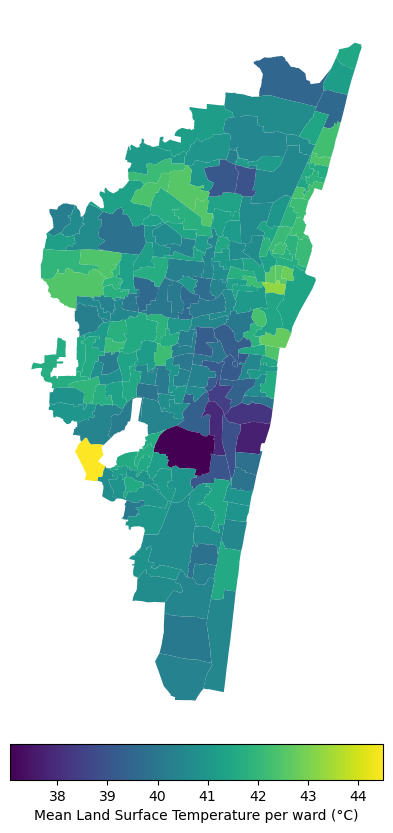

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_wards_merged_summer.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)
plt.savefig(fig_path)
ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

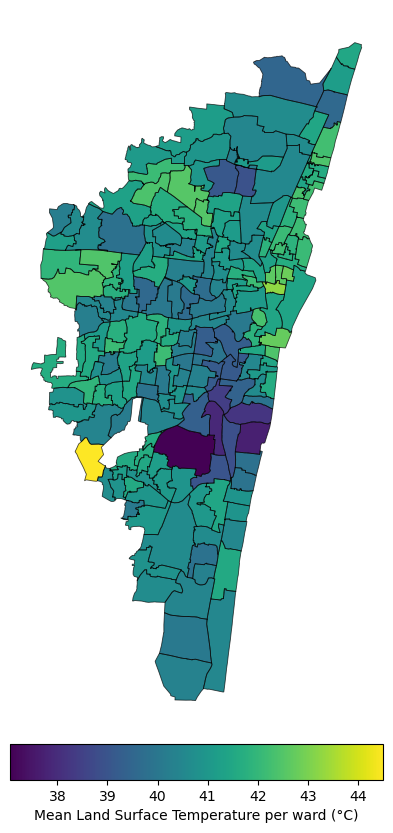

In [42]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_wards_merged_summer.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)

df_wards_merged_summer.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    alpha=0.7
)

plt.savefig(fig_path)
ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

In [43]:
## Also add tiny labels and change the color bar a bit:
## First, need to reproject

In [44]:
df_wards_summer_reproj = df_wards_merged_summer.to_crs(epsg=3857)

In [45]:
fig_path =  BASE_DIR / 'images' /'lst_ward_summer_chennai_band10_full_masked.png'

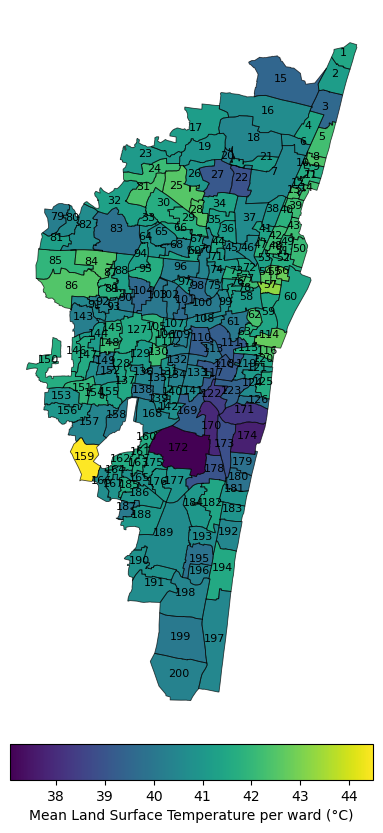

In [46]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

df_wards_summer_reproj["label_point"] = df_wards_summer_reproj.geometry.representative_point()

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_wards_summer_reproj.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)

df_wards_summer_reproj.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    alpha=0.7
)


for _, row in df_wards_summer_reproj.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row["Name"],
        fontsize=8,
        ha="center",
    )

ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

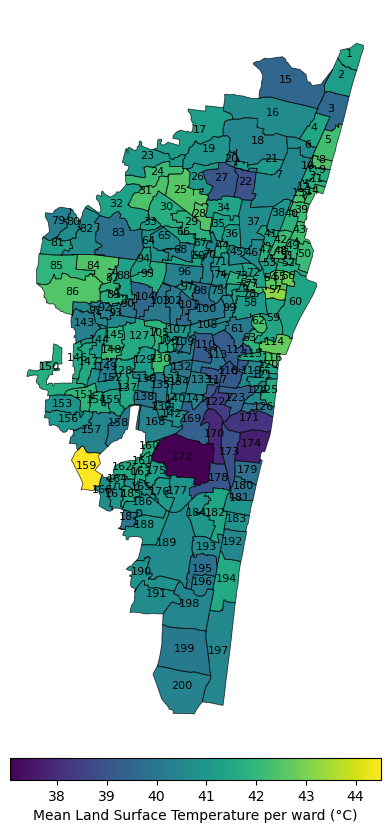

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

df_wards_summer_reproj["label_point"] = df_wards_summer_reproj.geometry.representative_point()

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

df_wards_summer_reproj.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)

df_wards_summer_reproj.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    alpha=0.7
)


for _, row in df_wards_summer_reproj.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row["Name"],
        fontsize=8,
        ha="center",
    )

ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

## References

T. Chakraborty, 2023, “Heat islands,” in Cloud-based remote sensing with Google Earth Engine, J. A. Cardille, M. A. Crowley, D. Saah and N. E. Clinton, Eds. Springer Open, [Online] Available: https://link.springer.com/book/10.1007/978-3-031-26588-4

Gandhi, Ujaval, 2021. End-to-End Google Earth Engine Course. Spatial Thoughts. https://courses.spatialthoughts.com/end-to-end-gee.html

Wu, Q. (2023). Earth Engine and Geemap. Geospatial Datascience with Python (1st ed.). Locate Press.  https://doi.org/10.21105/joss.02305 